In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar, Tz=1.0):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar) * Tz

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        assert out_dim % 2 == 0, "out_dim must be even: 2 * D"
        self.D = out_dim//2
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :self.D], out[..., self.D:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, zdim=3, system_type="bistable", cond_type="piri"):
        super().__init__()
        
        assert system_type in ("bistable", "dimer")
        assert cond_type in ("piri", "piririm", "pipimri", "pidqiri")
        self.system_type = system_type
        self.cond_type = cond_type
        self.zdim = zdim
        
        if system_type=="bistable":
            self.idim = 3
            if cond_type == "piri":
                self.cdim = 6
            elif cond_type in ("piririm", "pipimri"):
                self.cdim = 9
                
        elif system_type=="dimer":
            self.idim = 6
            if cond_type == "piri":
                self.cdim = 12
            elif cond_type == "pidqiri":
                self.cdim = 13 # ??
        
        # networks
        self.encoder = MLP(self.idim + self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.decoder = DiagGaussianHead(zdim + self.cdim, 2*self.idim)
        
        # normalisers
        self.scaler_r = None
        self.scaler_c = None
        
    def attach_normalizers(self, scaler_r, scaler_c):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_r = scaler_r
        self.scaler_c = scaler_c

    def encode(self, r_next, c):
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        p = self.prior(c)
        p_mu, p_logv = p.split(self.zdim, dim=-1)
        return p_mu, p_logv

    def decode(self, z, c):
        mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        return mu, log_sig

    def forward(self, r_next, c):
        p_mu, p_logv = self.prior_params(c)
        q_mu, q_logv = self.encode(r_next, c)
        z = reparam(q_mu, q_logv)
        dec_out = self.decode(z, c)
        return dec_out, (q_mu, q_logv), (p_mu, p_logv)   
    
    # ----- sampling ----- #
    @torch.no_grad()
    def sample_torch(self, c, Tr=1.0, Tz=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        p_mu, p_logv = self.prior_params(c)
        z = reparam(p_mu, p_logv, Tz=Tz)  # sample from p(z|c)
        
        mu, log_sig = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * Tr
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=None):
        """
        Sample r_{n+1} in physical units given c_n_np in physical units as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., cdim)
            Tr (float): temperature scaling factor for stochasticity
            Tz (float): temperature scaling factor in latent space for stochasticity
            device (torch.device): GPU/CPU device to use (optional)
            
        Handles every conditioning type provided the corresponding scaler.

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device

        # ---- Reshape and normalise ---- #
        c_n_np = np.asarray(c_n_np, dtype=np.float32)
        single_sample = False
        if c_n_np.ndim == 1:
            c_n_np = c_n_np.reshape(1, -1)
            single_sample = True
            
        c_norm = self.scaler_c.transform(c_n_np)

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)

        r_next_norm_t = self.sample_torch(c_t, Tr=Tr, Tz=Tz)

        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm_t.cpu().numpy()
        r_next_phys = self.scaler_r.inverse_transform(r_next_np)

        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [14]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., idim]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

def flatten_batch_time(x: torch.Tensor):
    """
    Flatten [B, L, D...] → [B*L, D...]
    Leave [B, D...] unchanged.
    """
    if x.dim() <= 2:
        return x
    # x: [B, L, ...]
    B, L = x.shape[:2]
    return x.reshape(B * L, *x.shape[2:])

In [15]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up scheduler ----
        if epoch <= warmup_epochs:
            beta = beta_max * (epoch / warmup_epochs)
        else:
            beta = beta_max
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, c_n)
            r_next, c = [x.to(device) for x in batch]
            
            r_next = flatten_batch_time(r_next)
            c = flatten_batch_time(c)
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                dec_out, q, p = model(r_next, c)
                q_mu, q_logv = q
                p_mu, p_logv = p
                #ar_mu, p_logv = p
                mu_r, log_sig_r = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                #kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)

        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [16]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, c = [x.to(device) for x in batch]
        
        r_next = flatten_batch_time(r_next)
        c = flatten_batch_time(c)
        
        dec_out, q, p = model(r_next, c)
        q_mu, q_logv = q
        p_mu, p_logv = p
        mu_r, log_sig_r = dec_out
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [17]:
class RCDataset(Dataset):
    """
    Simple dataset serving (r_next, c) pairs.

    r_next_all : torch.Tensor [N, idim]
    c_all      : torch.Tensor [N, cdim]
    """
    def __init__(self, r_next_all, c_all):
        super().__init__()
        assert isinstance(r_next_all, torch.Tensor)
        assert isinstance(c_all, torch.Tensor)
        assert r_next_all.shape[0] == c_all.shape[0]

        self.r_next = r_next_all
        self.c      = c_all

    def __len__(self):
        return self.r_next.shape[0]

    def __getitem__(self, idx):
        return self.r_next[idx], self.c[idx]

class RVSeqDataset(Dataset):
    """
    Dataset of sliding windows over trajectories of (r_next, c).

    Args
    ----
    r_next_seq : torch.Tensor, shape [N_traj, T, idim]
        r_{n+step} (or whatever you've precomputed per time step)
    c_seq      : torch.Tensor, shape [N_traj, T, cdim]
        conditioning vectors c_n
    L          : int >= 1
        window length (L=1 gives single-step windows)
    step       : int >= 1
        stride between window starts (in time indices)

    Returns
    -------
    __getitem__(idx) -> (r_win, c_win):
        r_win : [L, idim]
        c_win : [L, cdim]
    """
    def __init__(self,
                 r_next_seq: torch.Tensor,
                 c_seq: torch.Tensor,
                 L: int,
                 step: int = 1):
        super().__init__()

        assert isinstance(r_next_seq, torch.Tensor)
        assert isinstance(c_seq, torch.Tensor)
        assert r_next_seq.ndim == 3, "r_next_seq must be [N_traj, T, idim]"
        assert c_seq.ndim == 3, "c_seq must be [N_traj, T, cdim]"
        assert r_next_seq.shape[:2] == c_seq.shape[:2], \
            "r_next_seq and c_seq must match in [N_traj, T]"
        assert L >= 1, "L must be >= 1"
        assert step >= 1, "step must be >= 1"

        self.r_next_seq = r_next_seq       # [N_traj, T, 3]
        self.c_seq      = c_seq            # [N_traj, T, cdim]
        self.L = L
        self.step = step

        self.N_traj, self.T, _ = r_next_seq.shape
        if self.T < L:
            raise ValueError(
                f"Window length L={L} longer than trajectory length T={self.T}."
            )

        # windows start at t = 0, step, 2*step, ..., with t+L-1 < T
        self.windows_per_traj = (self.T - L) // step + 1
        self.total_windows = self.N_traj * self.windows_per_traj

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        traj_idx = idx // self.windows_per_traj
        win_idx  = idx %  self.windows_per_traj

        t_start = win_idx * self.step
        t_end   = t_start + self.L

        r_win = self.r_next_seq[traj_idx, t_start:t_end, :]   # [L, idim]
        c_win = self.c_seq[traj_idx,  t_start:t_end, :]       # [L, cdim]
        return r_win, c_win

In [18]:
def build_conditioning_and_scalers_OLD(q, v, r, cond_type=None, step: int = 1):
    """
    Build (r_next, c) and scalers based on a given conditioning type and time step.

    Args:
        q, v, r : torch tensors of shape [n_traj, n_steps, 3]
        cond_type : str, one of {"piri", "piririm", "pipimri"}
        step : int >= 1
            For step = k, conditioning is at time n and the target is r_{n+k}.
            For piririm / pipimri the "prev" term is at time n-k.

    Returns:
        r_next_all : [N, 3]  flattened r_{n+step}
        c_all      : [N, cdim] flattened conditioning vectors
        scaler_r   : fitted StandardScaler for r_next
        scaler_c   : fitted StandardScaler for conditioning variables
    """
    assert q.shape == v.shape == r.shape
    assert q.ndim == 3 and q.shape[-1] == 3, "Expect (n_traj, n_steps, 3) for q, v, r"
    assert step >= 1, "step must be a positive integer"

    n_traj, T, _ = q.shape
    k = step

    if cond_type == "piri":
        # n = 0 .. T - k - 1
        # r_next = r_{n+k}, v_n = v_n, r_n = r_n
        if T <= k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri'.")

        r_next = r[:, k:, :]          # r_{n+k}, indices k .. T-1
        v_n    = v[:, :-k, :]         # v_n,    indices 0 .. T-k-1
        r_n    = r[:, :-k, :]         # r_n,    indices 0 .. T-k-1

        c = torch.cat([v_n, r_n], dim=-1)  # [..., 6]

    elif cond_type == "piririm":
        # Generalisation of:
        #   step=1: r_next = r[:, 2:], v_n = v[:, 1:-1], r_n = r[:, 1:-1], r_prev = r[:, :-2]
        #
        # For generic k:
        #   r_next = r_{n+k}    → indices j = 2k .. T-1
        #   v_n    = v_n        → indices j-k = k .. T-k-1
        #   r_n    = r_n        → indices k .. T-k-1
        #   r_prev = r_{n-k}    → indices j-2k = 0 .. T-2k-1
        if T <= 2 * k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm'.")

        r_next = r[:, 2*k:, :]        # r_{n+k}
        v_n    = v[:, k:-k, :]        # v_n
        r_n    = r[:, k:-k, :]        # r_n
        r_prev = r[:, :-2*k, :]       # r_{n-k}

        c = torch.cat([v_n, r_n, r_prev], dim=-1)  # [..., 9]

    elif cond_type == "pipimri":
        # Generalisation of:
        #   step=1: r_next = r[:, 2:], v_n = v[:, 1:-1], r_n = r[:, 1:-1], v_prev = v[:, :-2]
        #
        # For generic k:
        #   r_next = r_{n+k}    → indices j = 2k .. T-1
        #   v_n    = v_n        → indices j-k = k .. T-k-1
        #   r_n    = r_n        → indices k .. T-k-1
        #   v_prev = v_{n-k}    → indices j-2k = 0 .. T-2k-1
        if T <= 2 * k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pipimri'.")

        r_next = r[:, 2*k:, :]        # r_{n+k}
        v_n    = v[:, k:-k, :]        # v_n
        r_n    = r[:, k:-k, :]        # r_n
        v_prev = v[:, :-2*k, :]       # v_{n-k}

        c = torch.cat([v_n, v_prev, r_n], dim=-1)

    else:
        raise ValueError(
            f"Unknown conditioning type: {cond_type}. "
            "Expected one of {'piri', 'piririm', 'pipimri'}."
        )

    # shapes: [n_traj, T_eff, ...]
    # print(r_next.shape, c.shape)

    # flatten trajectories → samples
    r_next_all = r_next.reshape(-1, 3)
    c_all      = c.reshape(-1, c.shape[-1])

    # ---- fitting scalers ----
    # (assumes tensors are on CPU; move to .cpu() if needed)
    scaler_c = StandardScaler().fit(c_all.numpy())
    scaler_r = StandardScaler().fit(r_next_all.numpy())

    # you can keep them as torch tensors; scaler expects numpy only during fit/transform
    return r_next_all, c_all, scaler_r, scaler_c

In [20]:
def minimal_image_rel(q1, q2, boxsize=None, boundary_type='periodic'):
    """
    q1, q2: [..., 3] torch tensors
    returns q2 - q1 with minimal-image convention matching trajectoryTools.relativePosition
    """
    rel = q2 - q1  # [..., 3]

    if boundary_type == "periodic" and boxsize is not None:
        # box: tensor of shape [3]
        if isinstance(boxsize, (list, tuple, np.ndarray)):
            box = torch.tensor(boxsize, dtype=rel.dtype, device=rel.device)
        else:  # scalar -> same in all dims
            box = torch.full((3,), float(boxsize), dtype=rel.dtype, device=rel.device)

        # broadcast box over leading dims, minimal image per component
        rel = rel - box * torch.round(rel / box)

    return rel

def compute_axisRelVel(q1, q2, v1, v2, boxsize, boundary_type="periodic"):
    """
    Computes axis-relative velocity for a dimer in a fully vectorised way.

    Inputs:
      q1, q2: positions  [..., 3]
      v1, v2: velocities [..., 3]
      boxsize: scalar or 3-vector
      boundary_type: "periodic" or "none"

    Returns:
      axisRelVel: tensor [..., 1]
    """

    # Minimal-image relative position
    rel_pos = minimal_image_rel(q1, q2, boxsize, boundary_type)   # [..., 3]

    # Relative velocity
    rel_vel = v2 - v1                                             # [..., 3]

    # Unit vector along dimer axis
    norm_rel = torch.norm(rel_pos, dim=-1, keepdim=True)          # [..., 1]
    unit_rel = rel_pos / (norm_rel + 1e-12)                       # avoid div-by-zero

    # Projection of relative velocity onto dimer axis
    axis_rel_vel = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=False)  # [..., 1]

    return axis_rel_vel

In [21]:
def build_conditioning_and_scalers(
    q: torch.Tensor,
    v: torch.Tensor,
    r: torch.Tensor,
    system_type: str = None,
    cond_type: str = None,
    step: int = 1
):
    """
    Build (r_next, c) and scalers based on a given conditioning type,
    time step, and system type ("bistable" or "dimer").

    Args
    ----
    q, v, r : torch.Tensor
        For system_type="bistable":
            shape [n_traj, n_steps, 3]
        For system_type="dimer":
            shape [n_traj, 2*n_steps, 3], with alternating particles:
                [:, 0::2, :] -> particle 1
                [:, 1::2, :] -> particle 2
    system_type : {"bistable", "dimer"}
    cond_type : str
        "piri", "piririm", "pipimri" (both systems)
        plus "pidqiri" (dimer only: (v1, v2, Δx, r1, r2)).
    step : int >= 1
        For step = k, conditioning is at time n and the target is r_{n+k}.
        For piririm / pipimri the "prev" term is at time n-k.

    Returns
    -------
    r_next_all : [N, idim]   flattened r_{n+step}
    c_all      : [N, cdim]   flattened conditioning vectors
    scaler_r   : StandardScaler fitted on r_next_all
    scaler_c   : StandardScaler fitted on c_all
    """
    assert q.shape == v.shape == r.shape
    assert step >= 1, "step must be a positive integer"

    system_type = system_type.lower()
    if system_type not in {"bistable", "dimer"}:
        raise ValueError(f"Unknown system_type='{system_type}', expected 'bistable' or 'dimer'.")

    # ---------- SINGLE-PARTICLE (BISTABLE) CASE ----------
    if system_type == "bistable":
        assert q.ndim == 3 and q.shape[-1] == 3, \
            "Expect (n_traj, n_steps, 3) for q, v, r in 'bistable'."

        n_traj, T, _ = q.shape
        k = step

        if cond_type == "piri":
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri'.")

            r_next = r[:, k:, :]      # r_{n+k}, j = k..T-1
            v_n    = v[:, :-k, :]     # v_n,    j = 0..T-k-1
            r_n    = r[:, :-k, :]     # r_n

            c = torch.cat([v_n, r_n], dim=-1)  # [..., 6]

        elif cond_type == "piririm":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm'.")

            r_next = r[:, 2*k:, :]    # r_{n+k}
            v_n    = v[:, k:-k, :]    # v_n
            r_n    = r[:, k:-k, :]    # r_n
            r_prev = r[:, :-2*k, :]   # r_{n-k}

            c = torch.cat([v_n, r_n, r_prev], dim=-1)  # [..., 9]

        elif cond_type == "pipimri":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pipimri'.")

            r_next = r[:, 2*k:, :]    # r_{n+k}
            v_n    = v[:, k:-k, :]    # v_n
            r_n    = r[:, k:-k, :]    # r_n
            v_prev = v[:, :-2*k, :]   # v_{n-k}

            c = torch.cat([v_n, v_prev, r_n], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type}. "
                "Expected one of {'piri', 'piririm', 'pipimri'} for 'bistable'."
            )

    # ---------- DIMER CASE ----------
    else:  # system_type == "dimer"
        # Here the time dimension is 2*T with alternating p1, p2 samples
        assert q.ndim == 3 and q.shape[-1] == 3, \
            "Expect (n_traj, 2*n_steps, 3) for q, v, r in 'dimer'."

        n_traj, T2, _ = q.shape
        if T2 % 2 != 0:
            raise ValueError("For 'dimer', time dimension must be even (alternating p1/p2 samples).")
        T = T2 // 2
        k = step

        def split_particles(x):
            # x1: particle 1, x2: particle 2
            return x[:, 0::2, :], x[:, 1::2, :]

        q1, q2 = split_particles(q)
        v1, v2 = split_particles(v)
        r1, r2 = split_particles(r)

        if cond_type == "piri":
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri' (dimer).")

            # targets
            r1_next = r1[:, k:, :]
            r2_next = r2[:, k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # conditioning at time n
            v1_n = v1[:, :-k, :]
            v2_n = v2[:, :-k, :]
            r1_n = r1[:, :-k, :]
            r2_n = r2[:, :-k, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n], dim=-1)  # [..., 12]

        elif cond_type == "piririm":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm' (dimer).")

            r1_next = r1[:, 2*k:, :]
            r2_next = r2[:, 2*k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, k:-k, :]
            v2_n = v2[:, k:-k, :]
            r1_n = r1[:, k:-k, :]
            r2_n = r2[:, k:-k, :]
            r1_prev = r1[:, :-2*k, :]
            r2_prev = r2[:, :-2*k, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n, r1_prev, r2_prev], dim=-1)

        elif cond_type == "pidqiri":
            # (v1, v2, Δx, r1, r2), with Δx = |x1 - x2| along the dimer axis
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pidqiri' (dimer).")

            r1_next = r1[:, k:, :]
            r2_next = r2[:, k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, :-k, :]
            v2_n = v2[:, :-k, :]
            r1_n = r1[:, :-k, :]
            r2_n = r2[:, :-k, :]

            # positions at time n (for Δx_n)
            q1_n = q1[:, :-k, :]
            q2_n = q2[:, :-k, :]
            
            # minimal-image relative vector and norm
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5)               # [..., 3]
            delta_x = torch.norm(rel, dim=-1, keepdim=True)

            c = torch.cat([v1_n, v2_n, delta_x, r1_n, r2_n], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type} for 'dimer'. "
                "Expected one of {'piri', 'piririm', 'pipimri', 'pidqiri'}."
            )

    # ---------- FLATTEN + SCALERS (COMMON) ----------
    # shapes: [n_traj, T_eff, ...] -> [N, ...]
    r_next_all = r_next.reshape(-1, r_next.shape[-1])
    c_all      = c.reshape(-1, c.shape[-1])

    scaler_c = StandardScaler().fit(c_all.cpu().numpy())
    scaler_r = StandardScaler().fit(r_next_all.cpu().numpy())

    return r_next_all, c_all, scaler_r, scaler_c

In [38]:
# System type: 'bistable', 'dimer'
systemType = 'dimer' #'dimer'
# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'pidqiri'

In [39]:
# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[   0    9   21   23   26   34   87  108  166  182  186  188  245  247
  254  264  266  326  352  357  370  390  399  418  421  429  433  442
  443  447  459  475  478  483  530  559  563  581  586  590  592  595
  602  616  651  672  710  716  723  733  750  761  766  783  785  787
  806  815  821  827  845  858  864  876  887  891  901  915  918  925
  931  933  963  968  974  980  983  998 1004 1010 1043 1048 1061 1068
 1077 1081 1085 1095 1132 1149 1175 1195 1198 1238 1245 1255 1287 1296
 1297 1301 1310 1314 1319 1328 1329 1336 1366 1387 1398 1401 1433 1477
 1498 1499 1501 1504 1527 1539 1543 1544 1559 1578 1587 1629 1651 1653
 1660 1685 1698 1704 1715 1733 1756 1758 1764 1767 1768 1770 1778 1779
 1786 1790 1792 1804 1813 1815 1821 1830 1834 1840 1845 1859 1865 1882
 1907 1926 1953 1957 1963 1968 1976 1981 1985 1989 1991 2027 2051 2059
 2108 2121 2126 2151 2153 2175 2182 2205 2206 2226 2241 2257 2261 2290
 2305 2321 2376 2386 2410 2416 2419 2438 2447 2450 2458 2468 2475 2481
 2486 

(torch.Size([200, 20000, 11]), torch.Size([4000000, 11]), 20000, torch.float32)

In [40]:
integratorStride = 1

q = dataset[..., 1:4]  # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

print(q.shape, v.shape, r.shape)

r_next, c, scaler_r, scaler_c = build_conditioning_and_scalers(q, v, r, system_type=systemType, cond_type=conditionedOn, step=integratorStride)

r_next_norm = torch.tensor(scaler_r.transform(r_next), dtype=torch.float32)
c_norm = torch.tensor(scaler_c.transform(c), dtype=torch.float32)

torch.Size([200, 20000, 3]) torch.Size([200, 20000, 3]) torch.Size([200, 20000, 3])


In [41]:
r_next.shape, c.shape, r_next.std(), r_next_norm.std(), c.std(dim=(0)), c_norm.std()

(torch.Size([1999800, 6]),
 torch.Size([1999800, 13]),
 tensor(0.0160),
 tensor(1.),
 tensor([0.1418, 0.1420, 0.1424, 0.1418, 0.1425, 0.1425, 0.3551, 0.0160, 0.0160,
         0.0161, 0.0160, 0.0161, 0.0161]),
 tensor(1.))

In [42]:
# N_flat total samples
N = len(r_next_norm)
assert N % n_datasets == 0, "r_next_norm must be divisible by n_datasets"

# --- hyper-params ---
stride = 1          # set to 2, 3, 5, ... to subsample in time
L = 4               # window length for RVSeqDataset

if systemType=="bistable":
    # full time length per trajectory in the *original* dataset
    T_full = dataset.shape[1]

    # effective number of r_{n+1} steps per trajectory (before stride)
    if conditionedOn == 'piri':
        T_eff = T_full - 1*integratorStride          # r_{n+1} exists for n = 0..T_full-2
    elif conditionedOn in ("piririm", "pipimri"):
        T_eff = T_full - 2*integratorStride          # you lose an extra step for r_{n-1}
    else:
        raise ValueError(f"Unknown conditioning: {conditionedOn}")
        
elif systemType=="dimer":
    # full time length per trajectory in the *original* dataset divided by 2
    T_full = dataset.shape[1]//2
    
    # effective number of r_{n+1} steps per trajectory (before stride)
    if conditionedOn in ('piri', 'pidqiri'):
        T_eff = T_full - 1*integratorStride          # r_{n+1} exists for n = 0..T_full-2
    elif conditionedOn in ("piririm"):
        T_eff = T_full - 2*integratorStride          # you lose an extra step for r_{n-1}
    else:
        raise ValueError(f"Unknown conditioning: {conditionedOn}")

# reshape flat arrays → [n_datasets, T_eff, ...]
r_next_traj = r_next_norm.view(n_datasets, T_eff, -1)
c_traj      = c_norm.view(n_datasets, T_eff, -1)

# Sliding-window dataset: sequences of length L
split_traj = int(0.8 * n_datasets)

train_ds = RVSeqDataset(
    r_next_traj[:split_traj],   # [N_train, T_eff_strided, 3]
    c_traj[:split_traj],        # [N_train, T_eff_strided, cdim]
    L=L,
    step=stride
)
val_ds = RVSeqDataset(
    r_next_traj[split_traj:],
    c_traj[split_traj:],
    L=L,
    step=stride
)

In [43]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

zdim = 3
model = CVAE(zdim=zdim, system_type=systemType, cond_type=conditionedOn).to(device)

In [44]:
## Saving Scaler Params
joblib.dump(
    {
        "scaler_r": scaler_r,
        "scaler_c": scaler_c
    },
    f"normalizers/normalizers_{systemType}_{conditionedOn}_stride{integratorStride}.pkl"
)

['normalizers/normalizers_dimer_pidqiri_stride1.pkl']

In [45]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.1,
                    warmup_epochs=10,
                    grad_clip=1.0,
                    save_path=f"ckpts/cvae_checkpoint_{systemType}_{conditionedOn}_stride{integratorStride}.pt")

Epoch 1/50: 100%|██████████████████████████████| 391/391 [00:08<00:00, 48.51it/s, KL=8.26, NLL=-1.3, loss=-0.393]


Epoch 1: loss=1.5547, NLL=0.8989, KL=5.9619


Epoch 2/50: 100%|████████████████████████████████| 391/391 [00:07<00:00, 51.86it/s, KL=8.29, NLL=0.11, loss=1.93]


Epoch 2: loss=0.8807, NLL=-0.7637, KL=7.4746


Epoch 3/50: 100%|██████████████████████████████| 391/391 [00:07<00:00, 50.70it/s, KL=7.55, NLL=-1.94, loss=0.546]


...

Epoch 49/50: 100%|███████████████████████████████| 391/391 [00:07<00:00, 51.13it/s, KL=1.07, NLL=1.28, loss=2.46]


Epoch 49: loss=2.4457, NLL=1.2778, KL=1.0618


Epoch 50/50: 100%|████████████████████████████████| 391/391 [00:07<00:00, 52.48it/s, KL=1.05, NLL=1.24, loss=2.4]

Epoch 50: loss=2.4454, NLL=1.2771, KL=1.0621


Validation loss: 2.4584


In [19]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

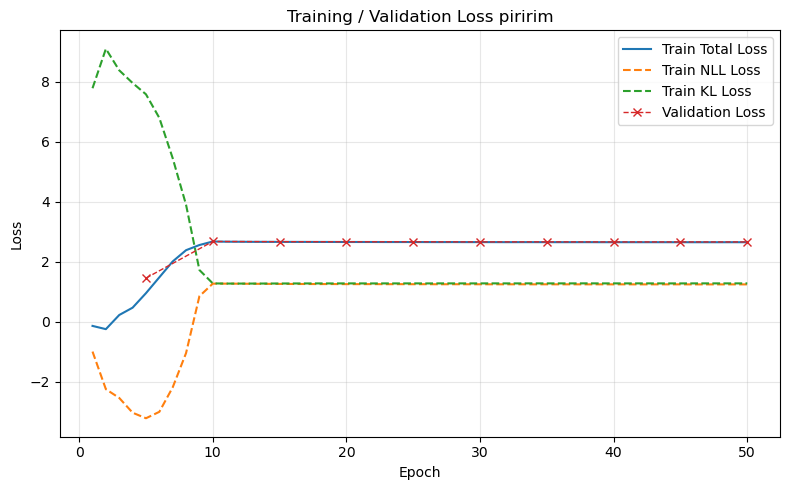

In [20]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training / Validation Loss {conditionedOn}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
valModel = CVAE(zdim=zdim, system_type=systemType, cond_type=conditionedOn).to(device)

scalers = joblib.load(f"normalizers/normalizers_{systemType}_{conditionedOn}_stride{integratorStride}.pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load(f"ckpts/cvae_checkpoint_{systemType}_{conditionedOn}_stride{integratorStride}.pt", map_location="cpu", weights_only=True)
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [42]:
def plot_r_distributions(model, r_next, c_n, n_samples=50000, device=device, Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.
    
    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors (v_n, r_n), shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]
    
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32)

    # --- Forward pass (reconstruction) ---
    model.eval()
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)
        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm = mu_r.cpu().numpy()
        r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        r_rec = model.scaler_r.inverse_transform(r_rec_norm.cpu())

        # --- Generated samples ---
        r_gen = model.sample(c_s, Tr=Tr, Tz=Tz)

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    
    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_next_s[:, i])
        kde_rec = gaussian_kde(r_rec[:, i])
        kde_gen = gaussian_kde(r_gen[:, i].flatten())

        xs = np.linspace(
            min(r_next_s[:, i].min(), r_rec[:, i].min(), r_gen[:, i].min()),
            max(r_next_s[:, i].max(), r_rec[:, i].max(), r_gen[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)
        ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
    return r_next_s, r_rec, r_gen
    
def visualize_latent_distributions(model, r_next, c_n, n_samples=50000, device=device):
    """
    Visualize latent space distributions for encoder vs conditional prior.

    Args:
        model: trained CVAE
        c_n (np.ndarray): conditioning variables (r_n, v_n)
        r_next (np.ndarray): true target variables (r_{n+1})
        n_samples (int): number of samples to analyze
        device: torch device
    """
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # Normalize
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32, device=device)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        _, (q_mu, q_logv), _ = model(r_next_norm, c_norm)
        p_mu, p_logv = model.prior_params(c_norm)
        q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
        p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)

    zdim = q_mu.shape[1]

    # --- Plot histograms of latent means ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [43]:
def plot_r_distributions(model, r_next, c_n,
                         n_samples=50000, device=device,
                         Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.

    Handles both:
      - single particle: r_next shape [N, 3]
      - dimer (two particles): r_next shape [N, 6], interpreted as
            (r1_x, r1_y, r1_z, r2_x, r2_y, r2_z)

    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors, shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3] or [N, 6]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # dimensionality check
    D = r_next_s.shape[1]
    if D not in (3, 6):
        raise ValueError(f"Expected r_next to have dim 3 or 6, got {D}.")

    # number of particles (1 or 2), each with 3 dims
    n_particles = D // 3

    # --- Normalise ---
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32)

    # --- Forward pass (reconstruction) ---
    model.eval()
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)

        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm_t = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        
        r_rec = model.scaler_r.inverse_transform(r_rec_norm_t.cpu().numpy())

        # --- Generated samples (already returns physical units) ---
        r_gen = model.sample(c_s, Tr=Tr, Tz=Tz)  # shape [N, D]

    # --- Plot ---
    # rows = n_particles (1 or 2), cols = 3 (x,y,z)
    fig, axes = plt.subplots(n_particles, 3, figsize=(14, 4 * n_particles), sharey=False)

    # make axes always 2D for uniform indexing
    if n_particles == 1:
        axes = np.expand_dims(axes, axis=0)   # shape -> [1, 3]

    coord_labels = ["x", "y", "z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for p in range(n_particles):
        for j in range(3):
            dim_idx = p * 3 + j  # 0..2 for particle 1, 3..5 for particle 2
            ax = axes[p, j]

            # KDEs for benchmark, reconstructed, generated
            kde_bench = gaussian_kde(r_next_s[:, dim_idx])
            kde_rec   = gaussian_kde(r_rec[:, dim_idx])
            kde_gen   = gaussian_kde(r_gen[:, dim_idx])

            xs = np.linspace(
                min(r_next_s[:, dim_idx].min(), r_rec[:, dim_idx].min(), r_gen[:, dim_idx].min()),
                max(r_next_s[:, dim_idx].max(), r_rec[:, dim_idx].max(), r_gen[:, dim_idx].max()),
                300,
            )

            ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[j], lw=2)
            ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
            ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

            part_label = f"r{p+1}_{coord_labels[j]}" if n_particles == 2 else f"r_{coord_labels[j]}"
            ax.set_title(f"Distribution of {part_label}")
            ax.set_xlabel(part_label)
            ax.set_ylabel("Density")
            ax.legend()

            # optional fixed x-limits (keep if you like; otherwise comment out)
            ax.set_xlim(-0.05, 0.05)

    plt.tight_layout()
    plt.show()

    return r_next_s, r_rec, r_gen

In [44]:
val_loader_full = DataLoader(val_ds, batch_size=8192, shuffle=False)
all_r, all_c = [], []

for r_win, c_win in val_loader_full:
    r_flat = r_win.reshape(-1, r_win.shape[-1])
    c_flat = c_win.reshape(-1, c_win.shape[-1])
    all_r.append(r_flat)
    all_c.append(c_flat)

r_next_val = torch.cat(all_r, dim=0)
c_val = torch.cat(all_c, dim=0)

r_val_ph = valModel.scaler_r.inverse_transform(r_next_val)
c_val_ph = valModel.scaler_c.inverse_transform(c_val)

/tmp/ipykernel_1587273/189791530.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
/tmp/ipykernel_1587273/189791530.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)


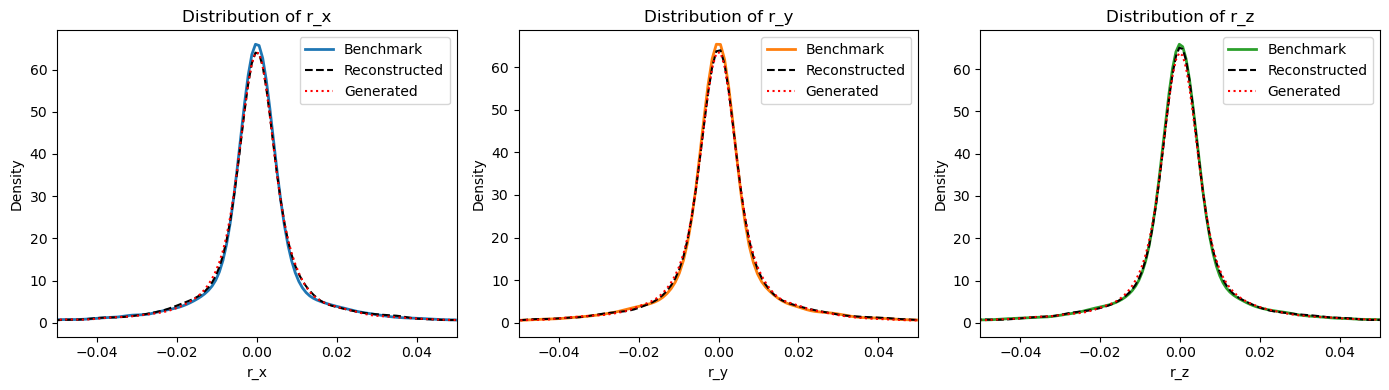

In [45]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N, idim])
# model = trained CVAE with attached scalers

r_bench, r_rec, r_gen = plot_r_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000, Tr=1, Tz=1)

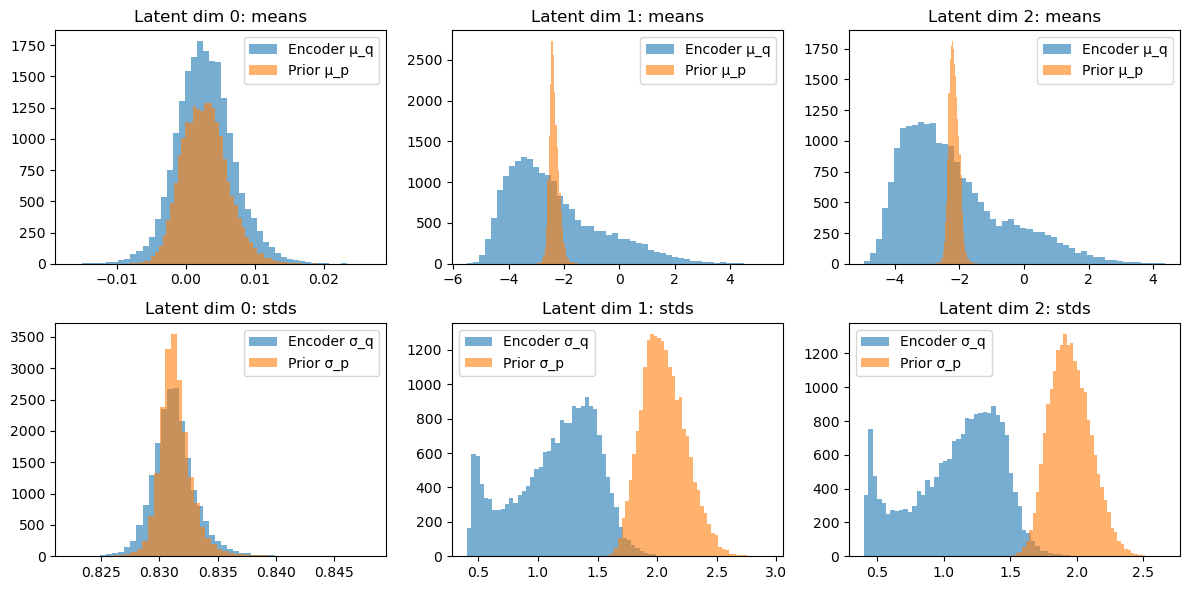

In [46]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000)

In [30]:
batch = next(iter(val_loader))
r_nxt_b, c_t = [x.to(device) for x in batch]

with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv) = valModel(r_nxt_b, c_t)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=1.026  p_std=1.617  decoder_sigma=0.540


In [31]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=1.617 q10=0.831 q50=1.874 q90=2.206
q_std: mean=1.026 q10=0.688 q50=0.887 q90=1.467
dec σ: mean=0.540 q10=0.150 q50=0.289 q90=1.402
